In [1]:
import warnings
from tqdm import TqdmExperimentalWarning

warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

from src import constants as cnsts 
from src.statsforecastlab import StatsForecastLab

In [2]:
sflab = StatsForecastLab(
    freq="h",
    normalization=True,
    # test=True
)

# sflab.create_folder_structure()

In [3]:
sflab.cross_validation()

Currently running: [72, 'root3', 'Naive']
Currently running: [72, 'root3', 'ARIMA']
Currently running: [72, 'root3', 'ARIMA_sl24']
Currently running: [72, 'root3', 'AutoARIMA']
Currently running: [72, 'root3', 'AutoARIMA_sl24']
Currently running: [72, 'root3', 'AutoETS']
Currently running: [72, 'root3', 'AutoETS_sl24']
Currently running: [72, 'outl', 'Naive']
Currently running: [72, 'outl', 'ARIMA']
Currently running: [72, 'outl', 'ARIMA_sl24']
Currently running: [72, 'outl', 'AutoARIMA']
Currently running: [72, 'outl', 'AutoARIMA_sl24']
Currently running: [72, 'outl', 'AutoETS']
Currently running: [72, 'outl', 'AutoETS_sl24']
Currently running: [72, 'identity', 'Naive']
Currently running: [72, 'identity', 'ARIMA']
Currently running: [72, 'identity', 'ARIMA_sl24']
Currently running: [72, 'identity', 'AutoARIMA']
Currently running: [72, 'identity', 'AutoARIMA_sl24']
Currently running: [72, 'identity', 'AutoETS']
Currently running: [72, 'identity', 'AutoETS_sl24']
Currently running: [48,

In [4]:
sflab.best_results_metric_dataframe(unique_ids=cnsts.JCUIds)


,metric,unique_id,metric_value,best_model,transformation
0,mae,HUFL,0.088415,AutoETS_sl24,identity
1,mae,LUFL,0.088547,AutoARIMA_sl24,outl
2,mae,MUFL,0.092515,AutoETS_sl24,identity
3,mae,MULL,0.068890,AutoETS_sl24,outl


In [5]:
sflab.best_results_summary(result="crossval")

,transformation,horizon,mean_mae
0,identity,72,0.056146
1,identity,48,0.053246
2,identity,24,0.052263


In [6]:
sflab.predict()

File already exists at results_norm\horizon=72\best_forecast.csv, skipping computation.
File already exists at results_norm\horizon=48\best_forecast.csv, skipping computation.
File already exists at results_norm\horizon=24\best_forecast.csv, skipping computation.


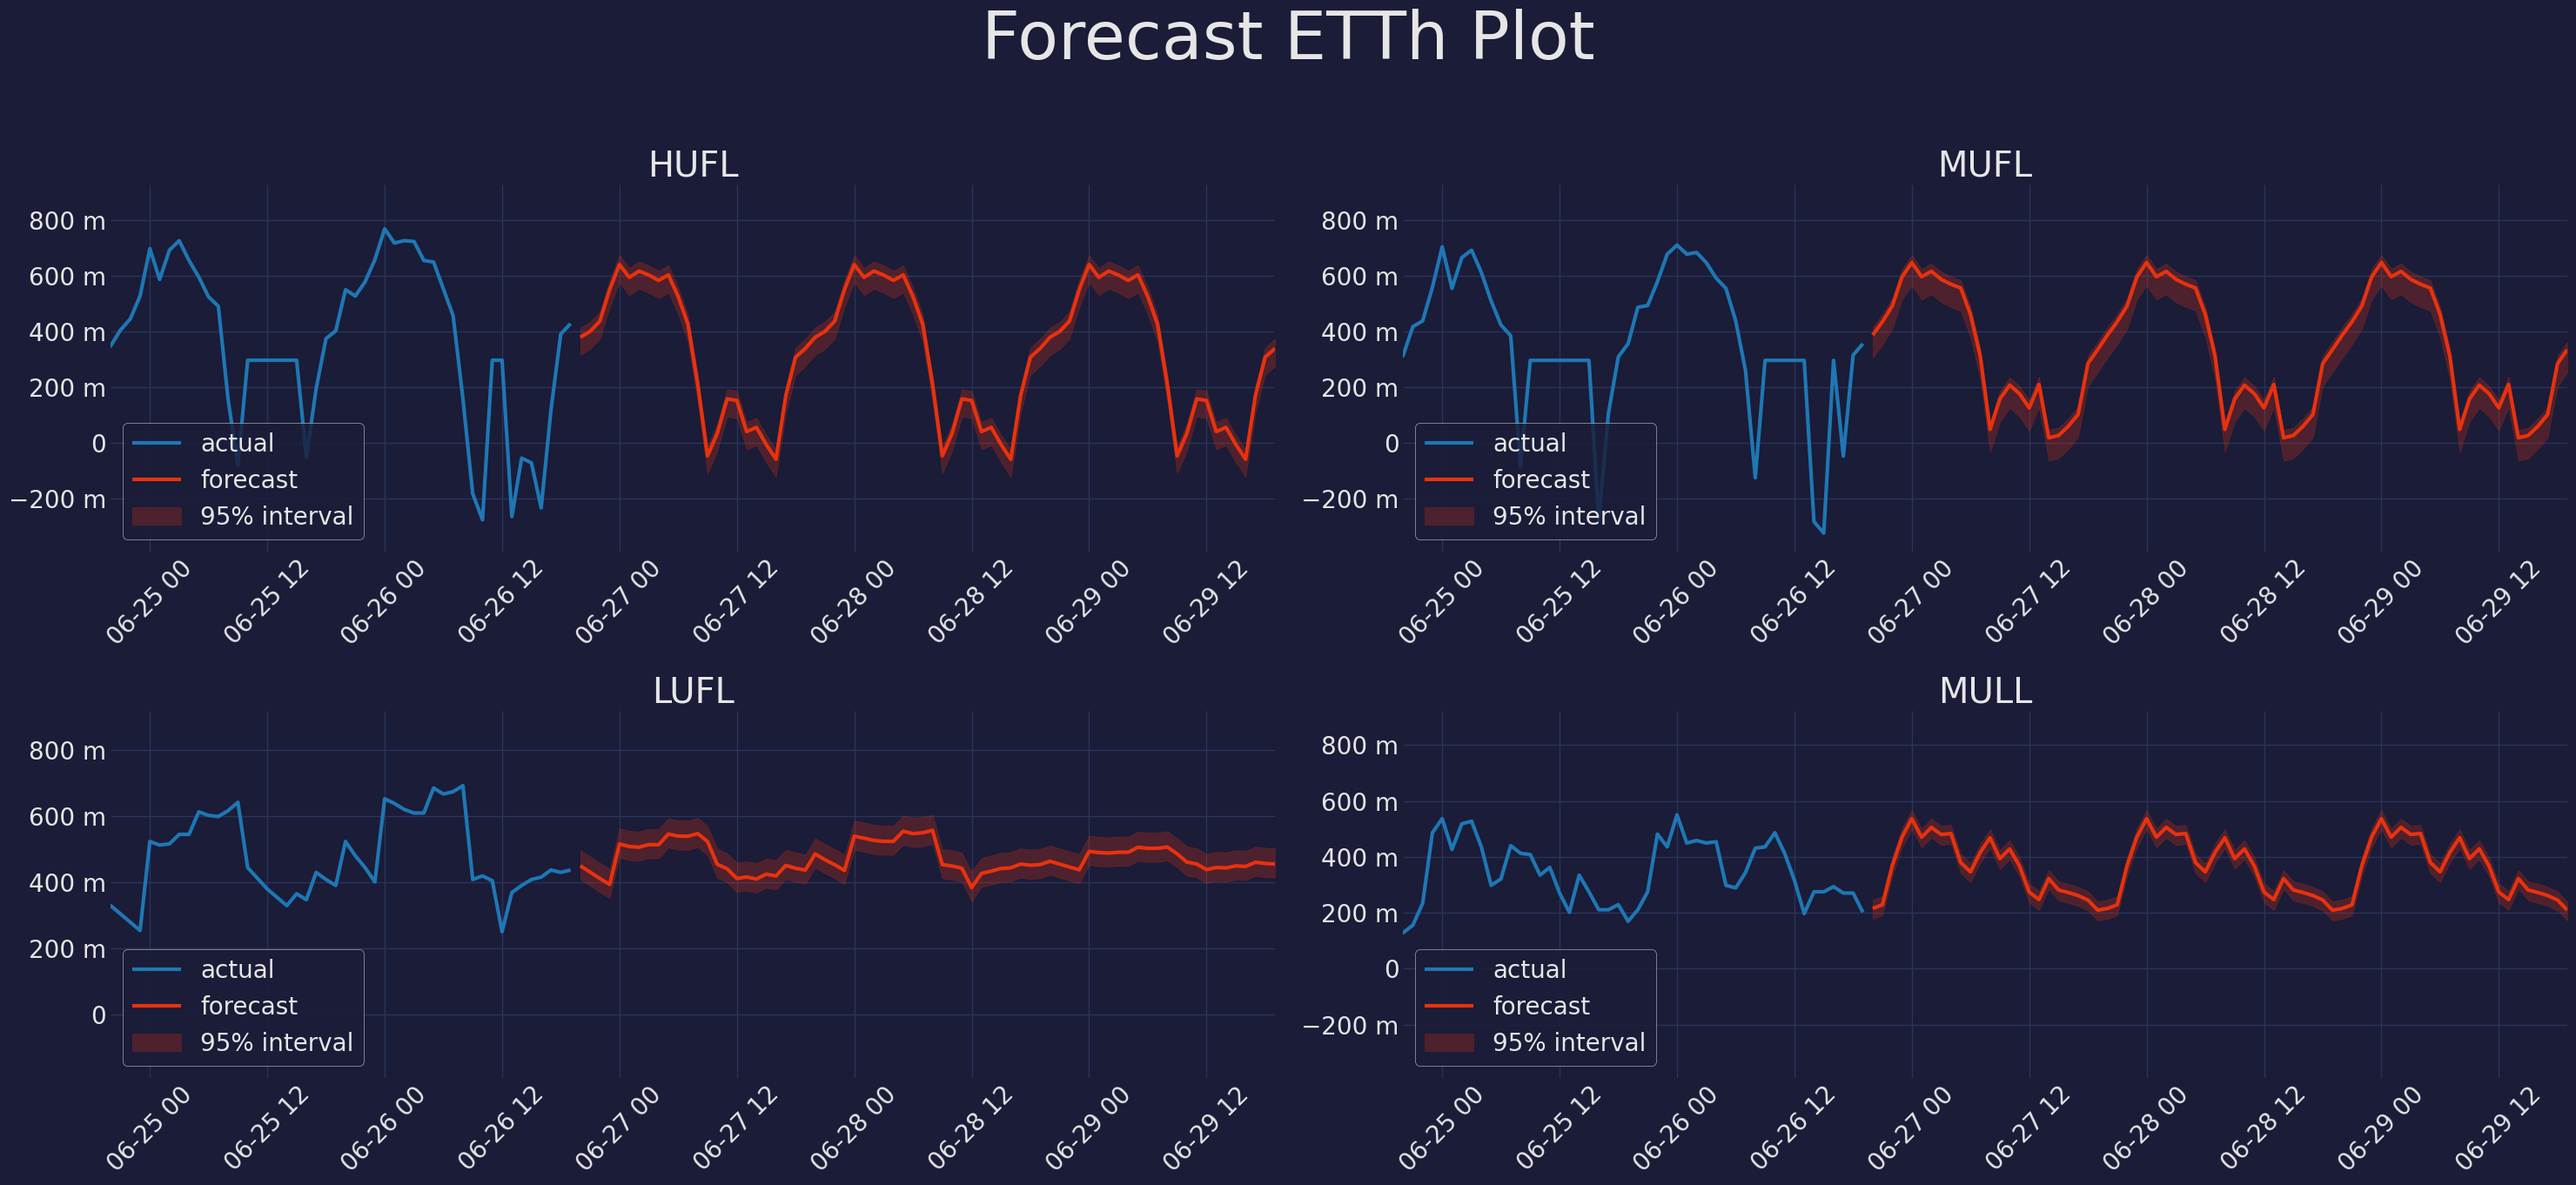

In [7]:
sflab.best_results_plots(
    horizon=72, 
    result="forecast", 
    actual=True, 
    eval_horizon=2, 
    unique_ids=cnsts.JCUIds
)

In [8]:
df=sflab.best_results_prediction_dataframe(unique_ids=cnsts.JCUIds)
df

,unique_id,ds,cutoff,value,prediction
0,HUFL,2018-05-17 19:00:00,2018-05-17 18:00:00,0.410760,0.339811
1,HUFL,2018-05-17 20:00:00,2018-05-17 18:00:00,0.470267,0.384750
2,HUFL,2018-05-17 21:00:00,2018-05-17 18:00:00,0.475935,0.418005
3,HUFL,2018-05-17 22:00:00,2018-05-17 18:00:00,0.439097,0.437037
4,HUFL,2018-05-17 23:00:00,2018-05-17 18:00:00,0.526899,0.589285
...,...,...,...,...,...
859,MULL,2018-06-26 15:00:00,2018-06-23 19:00:00,0.275203,0.219429
860,MULL,2018-06-26 16:00:00,2018-06-23 19:00:00,0.293533,0.193745
861,MULL,2018-06-26 17:00:00,2018-06-23 19:00:00,0.270685,0.184818
862,MULL,2018-06-26 18:00:00,2018-06-23 19:00:00,0.270685,0.158942


In [9]:
df = df[df['unique_id'] == 'HUFL']
df

,unique_id,ds,cutoff,value,prediction
0,HUFL,2018-05-17 19:00:00,2018-05-17 18:00:00,0.410760,0.339811
1,HUFL,2018-05-17 20:00:00,2018-05-17 18:00:00,0.470267,0.384750
2,HUFL,2018-05-17 21:00:00,2018-05-17 18:00:00,0.475935,0.418005
3,HUFL,2018-05-17 22:00:00,2018-05-17 18:00:00,0.439097,0.437037
4,HUFL,2018-05-17 23:00:00,2018-05-17 18:00:00,0.526899,0.589285
...,...,...,...,...,...
211,HUFL,2018-05-26 14:00:00,2018-05-23 18:00:00,0.005667,0.255657
212,HUFL,2018-05-26 15:00:00,2018-05-23 18:00:00,0.283285,0.243181
213,HUFL,2018-05-26 16:00:00,2018-05-23 18:00:00,0.345627,0.223197
214,HUFL,2018-05-26 17:00:00,2018-05-23 18:00:00,0.464600,0.214809


Unique_id: HUFL, min_date: 2018-05-17 19:00:00, max_date: 2018-05-26 18:00:00
Unique_id: LUFL, min_date: 2018-06-17 20:00:00, max_date: 2018-06-26 19:00:00
Unique_id: MUFL, min_date: 2018-05-17 19:00:00, max_date: 2018-05-26 18:00:00
Unique_id: MULL, min_date: 2018-06-17 20:00:00, max_date: 2018-06-26 19:00:00


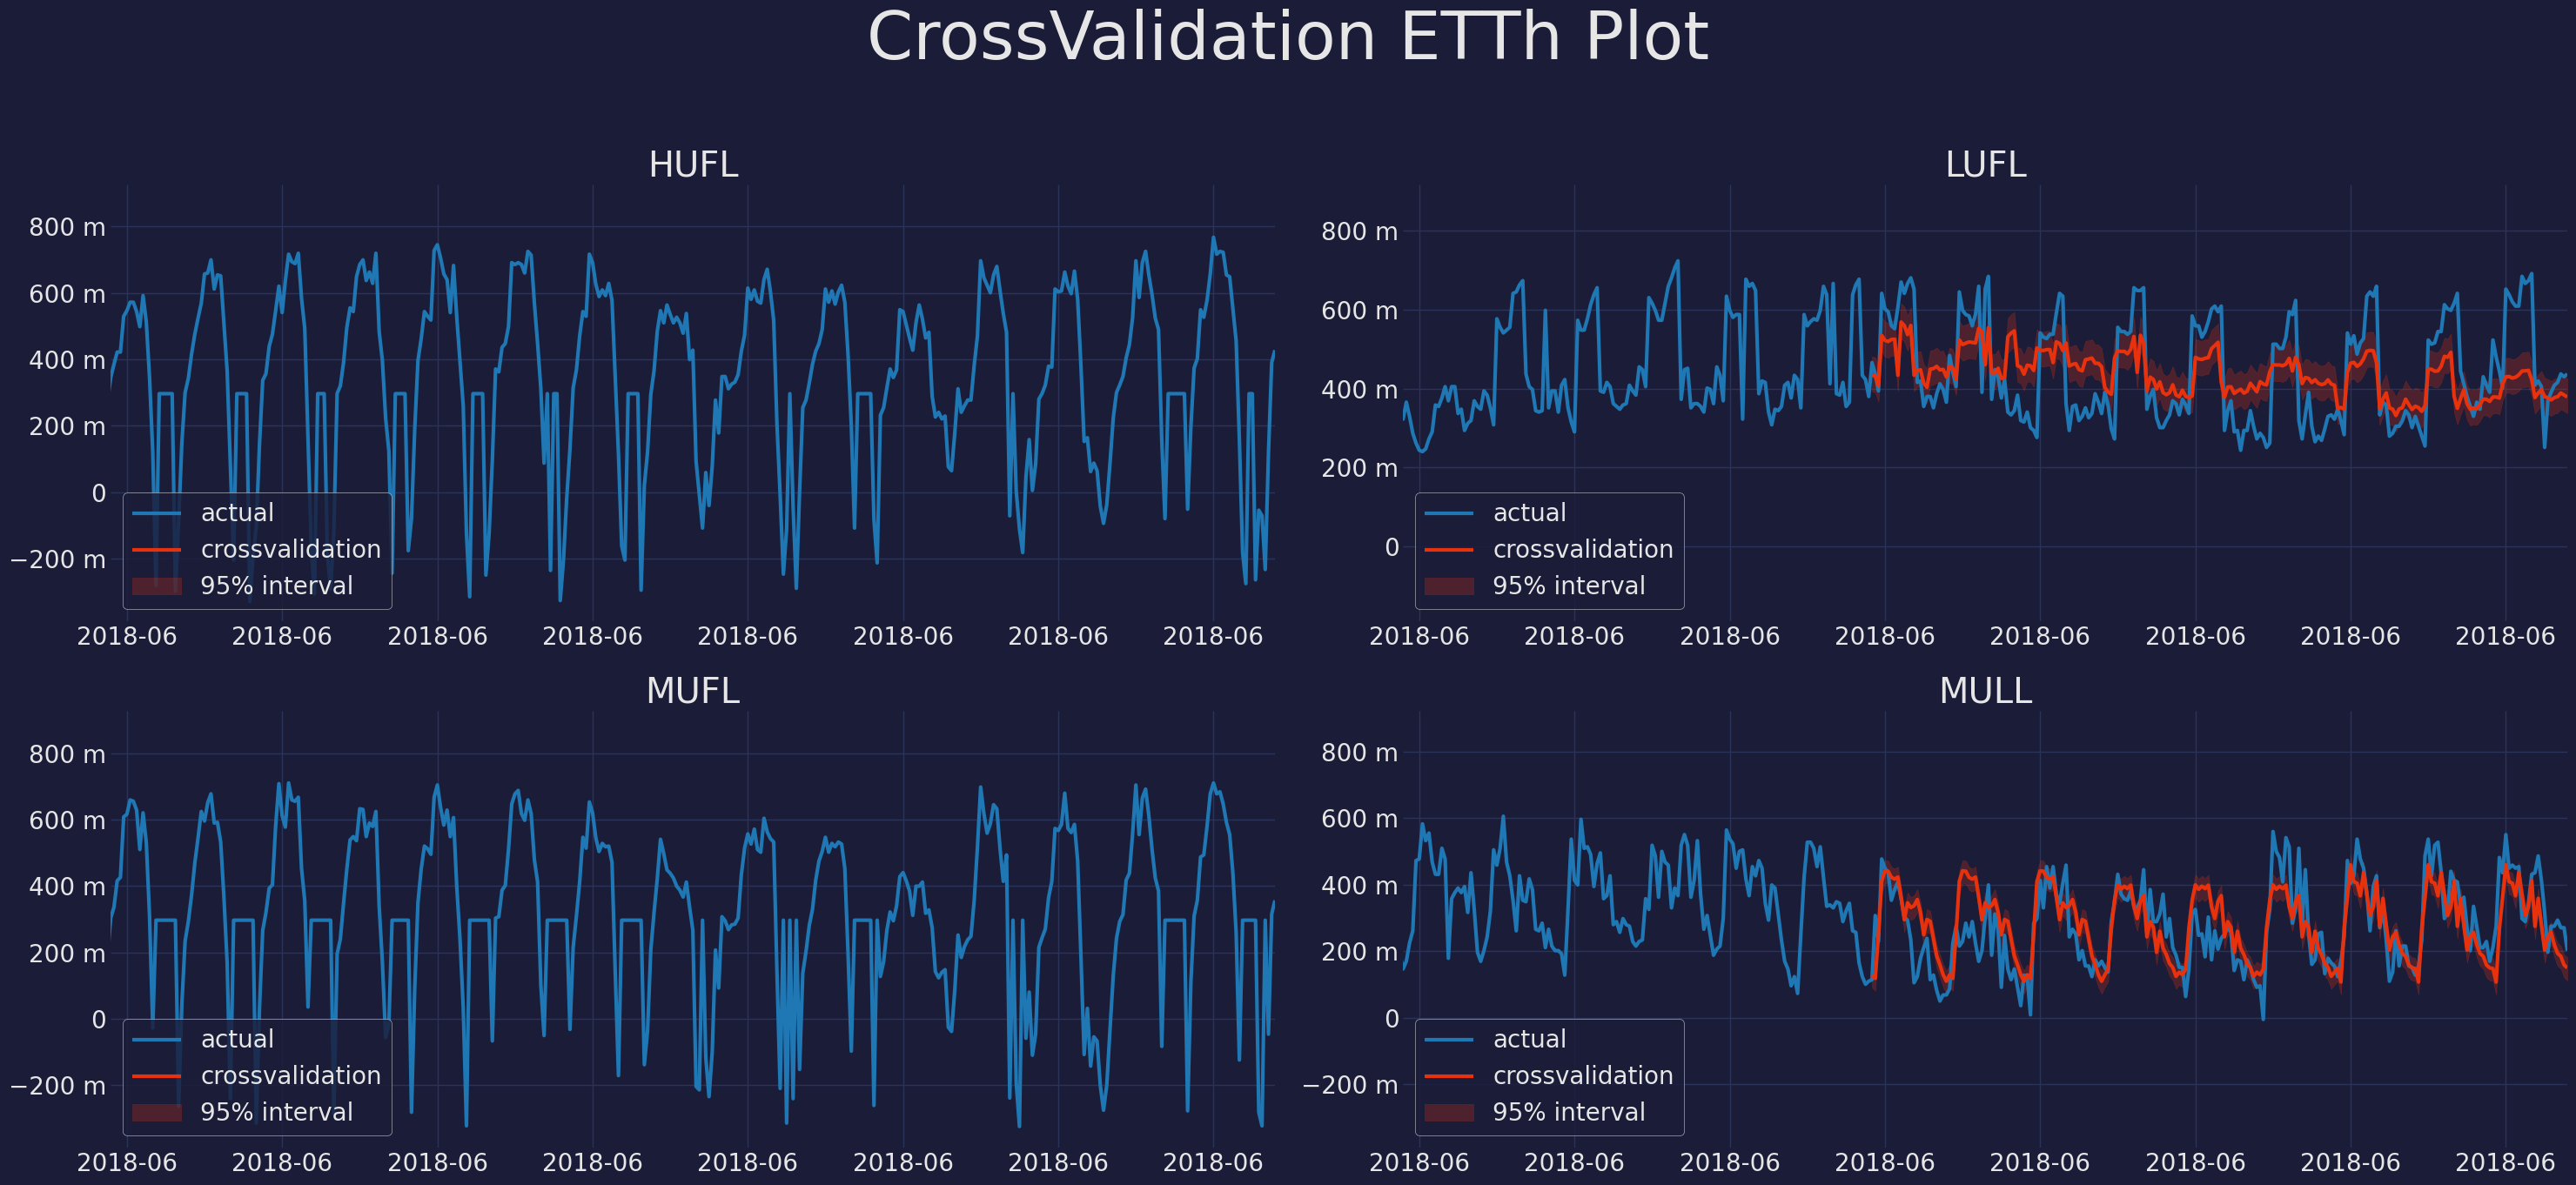

In [10]:
sflab.best_results_plots(
    horizon=72, 
    result="crossval", 
    actual=True, 
    eval_horizon=1, 
    # unique_ids=cnsts.JCUIds
    unique_ids=cnsts.JCUIds
)

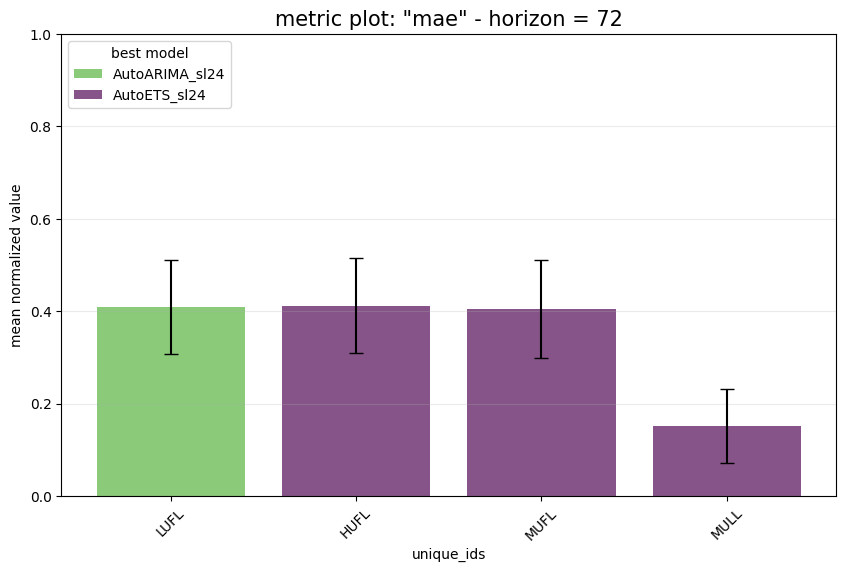

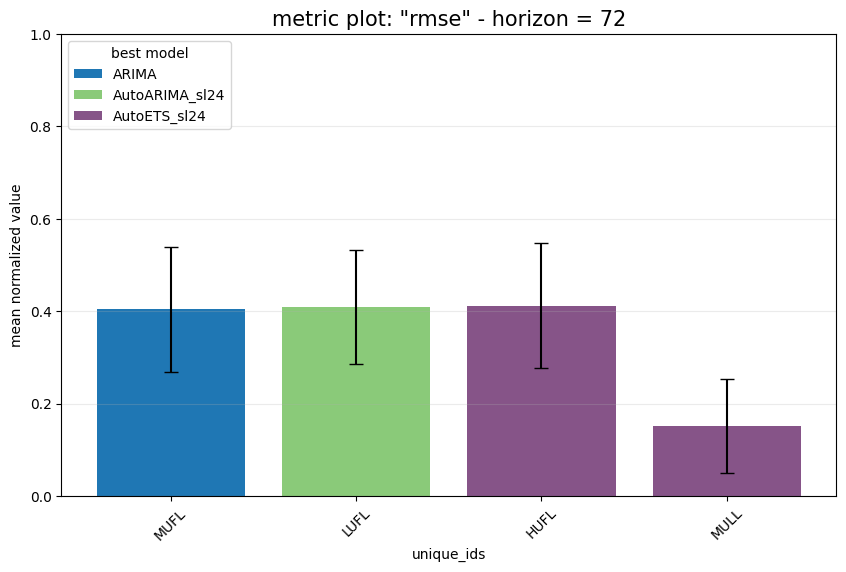

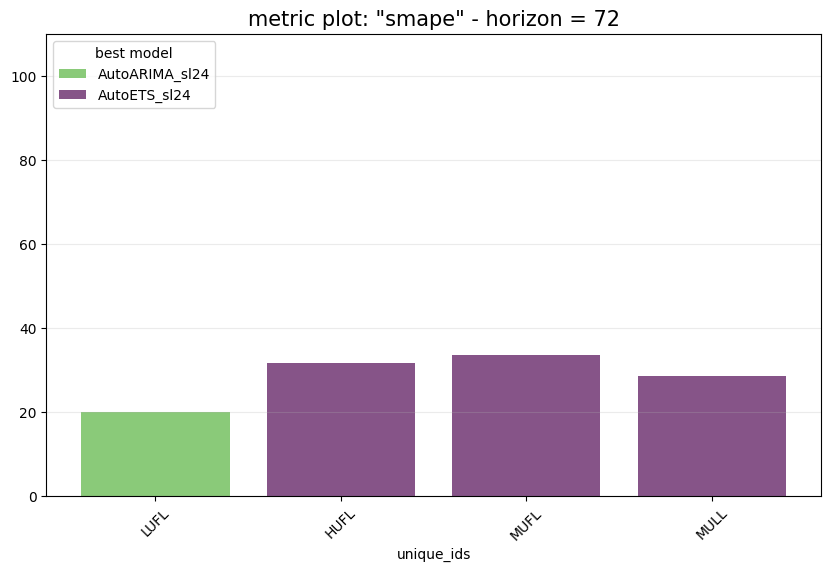

In [11]:
sflab.best_results_plots(
    horizon=72, 
    result="metrics", 
    unique_ids=cnsts.JCUIds
)